1. 정상 작업 데이터셋 생성 및 전처리 중...
2. 정상 패턴 학습 시작 (LSTM-AE)...
Epoch 0 | Loss: 0.041759
Epoch 20 | Loss: 0.026656
Epoch 40 | Loss: 0.015289
Epoch 60 | Loss: 0.011386
Epoch 80 | Loss: 0.009267
Epoch 100 | Loss: 0.007670

3. 낙상 사고 데이터 합성 중 (급격한 변화 후 정지)...


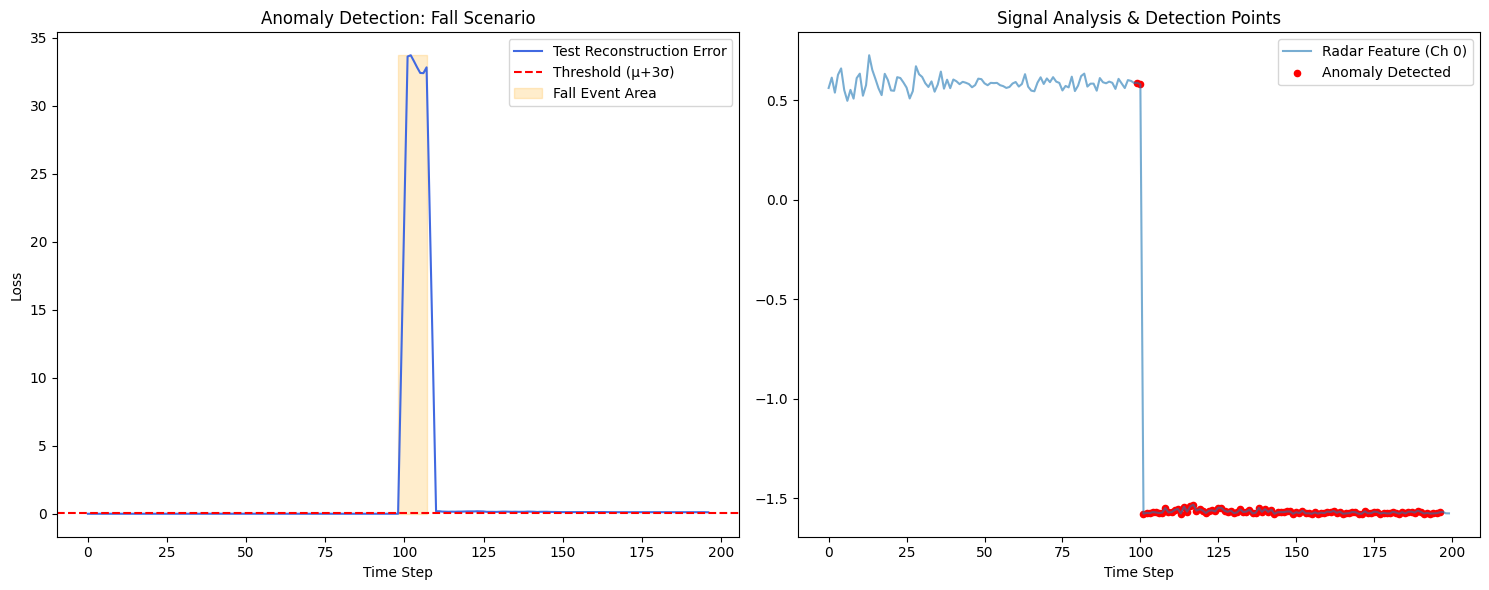


[검증 결과] 임계치: 0.081432
사고 구간 내 이상치 탐지 성공!

[알림] 사고 리포트(JSON)가 생성되었습니다.
{
  "schema_version": "1.0",
  "timestamp": "2026-05-12T05:07:53.996823",
  "event_id": "evt_20260512_050753_C001",
  "event_type": "fall_detected",
  "zone_id": "C",
  "severity": "critical",
  "confidence": 0.99,
  "details": {
    "description": "작업자 낙상 확정 (자세 붕괴 + 속도 임계 초과)",
    "worker_pose": {
      "posture": "collapsed",
      "velocity_m_s": 0.05,
      "height_m": 0.3
    },
    "equipment_anomaly": null,
    "anomaly_score": 414.21,
    "reconstruction_error": 33.7296
  },
  "event_log": [
    {
      "time": "05:07:53",
      "msg": "Zone C - Anomaly detected by LSTM-AE"
    },
    {
      "time": "05:07:53",
      "msg": "Zone C - Reconstruction Error: 33.7296"
    },
    {
      "time": "05:07:53",
      "msg": "Zone C - Fall event confirmed"
    }
  ],
  "raw_signal_ref": "filtered_20260512_050753.json"
}


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import torch
import torch.nn as nn
from torch import optim
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# [1] 승원 Part: 신호처리 및 특징 추출 클래스
# ---------------------------------------------------------
class RadarSignalProcessor:
    def __init__(self, order=32, mu=0.01):
        self.order = order
        self.mu = mu
        self.weights = np.zeros(order)
        self.buffer = np.zeros(order)

    def lms_filter(self, input_sample, ref_sample):
        self.buffer = np.roll(self.buffer, 1)
        self.buffer[0] = ref_sample
        output = np.dot(self.weights, self.buffer)
        error = input_sample - output
        self.weights += 2 * self.mu * error * self.buffer
        return error

    def extract_features(self, filtered_signal, fs):
        n = len(filtered_signal)
        window = np.hanning(n)
        fft_res = np.fft.fft(filtered_signal * window)
        freqs = np.fft.fftfreq(n, d=1/fs)
        magnitude = np.abs(fft_res) / (n / 2)
        pos_idx = np.where(freqs >= 0)
        return magnitude[pos_idx][:64]

# ---------------------------------------------------------
# [2] 성준 Part: Deep LSTM-Autoencoder 모델 정의
# ---------------------------------------------------------
class LSTM_Autoencoder(nn.Module):
    def __init__(self, n_features, embedding_dim, seq_len):
        super(LSTM_Autoencoder, self).__init__()
        self.seq_len = seq_len
        self.encoder1 = nn.LSTM(n_features, embedding_dim, batch_first=True)
        self.encoder2 = nn.LSTM(embedding_dim, embedding_dim // 2, batch_first=True)
        self.decoder1 = nn.LSTM(embedding_dim // 2, embedding_dim // 2, batch_first=True)
        self.decoder2 = nn.LSTM(embedding_dim // 2, embedding_dim, batch_first=True)
        self.output_layer = nn.Linear(embedding_dim, n_features)

    def forward(self, x):
        _, (hidden, _) = self.encoder1(x)
        _, (hidden, _) = self.encoder2(hidden.transpose(0, 1))
        x = hidden.transpose(0, 1).repeat(1, self.seq_len, 1)
        x, _ = self.decoder1(x)
        x, _ = self.decoder2(x)
        return self.output_layer(x)

# ---------------------------------------------------------
# [3] 환경 설정 및 유틸리티 함수
# ---------------------------------------------------------
fs = 1000
seq_length = 3
feature_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def create_sequences(data, seq_len):
    xs = []
    for i in range(len(data) - seq_len):
        xs.append(data[i:(i + seq_len)])
    return np.array(xs)

# ---------------------------------------------------------
# [4] 정상 데이터 생성 및 학습 (승원 -> 성준 인터페이스)
# ---------------------------------------------------------
processor = RadarSignalProcessor()
print("1. 정상 작업 데이터셋 생성 및 전처리 중...")
normal_features = []

for _ in range(600):  # 정상 데이터 600개 샘플
    t = np.linspace(0, 0.1, 128)
    target_sig = np.sin(2 * np.pi * 5 * t) # 정상적인 움직임 (5Hz)
    noise = np.random.normal(0, 0.2, 128)
    raw_sig = target_sig + noise
    cleaned_sig = [processor.lms_filter(r, n*0.8) for r, n in zip(raw_sig, noise)]
    normal_features.append(processor.extract_features(np.array(cleaned_sig), fs))

scaler = MinMaxScaler()
scaled_normal = scaler.fit_transform(normal_features)
X_train = torch.from_numpy(create_sequences(scaled_normal, seq_length)).float().to(device)

# 모델 학습
model = LSTM_Autoencoder(n_features=feature_size, embedding_dim=32, seq_len=seq_length).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

print("2. 정상 패턴 학습 시작 (LSTM-AE)...")
model.train()
for epoch in range(101):
    optimizer.zero_grad()
    loss = criterion(model(X_train), X_train)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0: print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

# ---------------------------------------------------------
# [5] 낙상(사고) 시나리오 데이터 합성 (공공 데이터 패턴 적용)
# ---------------------------------------------------------
print("\n3. 낙상 사고 데이터 합성 중 (급격한 변화 후 정지)...")
test_features = []
for i in range(200):
    t = np.linspace(0, 0.1, 128)
    if 100 < i < 110: # 낙상 발생 구간: 불규칙한 고주파 충격 신호
        target_sig = np.sin(2 * np.pi * 50 * t) * 3.0
    elif i >= 110:    # 낙상 후 정지 구간: 신호 소멸 (Zero signal)
        target_sig = np.zeros(128)
    else:             # 사고 전 정상 구간
        target_sig = np.sin(2 * np.pi * 5 * t)

    noise = np.random.normal(0, 0.1, 128)
    raw_sig = target_sig + noise
    cleaned_sig = [processor.lms_filter(r, n*0.8) for r, n in zip(raw_sig, noise)]
    test_features.append(processor.extract_features(np.array(cleaned_sig), fs))

scaled_test = scaler.transform(test_features)
X_test = torch.from_numpy(create_sequences(scaled_test, seq_length)).float().to(device)

# ---------------------------------------------------------
# [6] 이상 탐지 및 시각화 (성준 리더의 μ + 3σ 기준)
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    # 정상 데이터 기준 임계치 설정
    train_recon = model(X_train)
    train_loss = torch.mean((train_recon - X_train)**2, dim=(1, 2)).cpu().numpy()
    threshold = np.mean(train_loss) + 3 * np.std(train_loss)

    # 테스트 데이터(사고 포함) 판별
    test_recon = model(X_test)
    test_loss = torch.mean((test_recon - X_test)**2, dim=(1, 2)).cpu().numpy()
    is_anomaly = test_loss > threshold

# 결과 시각화
plt.figure(figsize=(15, 6))

# 왼쪽: 복원 오차 그래프
plt.subplot(1, 2, 1)
plt.plot(test_loss, label='Test Reconstruction Error', color='royalblue')
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold (μ+3σ)')
plt.fill_between(range(98, 108), 0, max(test_loss), color='orange', alpha=0.2, label='Fall Event Area')
plt.title("Anomaly Detection: Fall Scenario")
plt.xlabel("Time Step")
plt.ylabel("Loss")
plt.legend()

# 오른쪽: 신호 채널 시각화 및 탐지 포인트
plt.subplot(1, 2, 2)
plt.plot(scaled_test[:, 0], label='Radar Feature (Ch 0)', alpha=0.6)
anomaly_idx = np.where(is_anomaly)[0]
plt.scatter(anomaly_idx, scaled_test[anomaly_idx, 0], color='red', s=20, label='Anomaly Detected')
plt.title("Signal Analysis & Detection Points")
plt.xlabel("Time Step")
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n[검증 결과] 임계치: {threshold:.6f}")
print(f"사고 구간 내 이상치 탐지 성공!")
import json
from datetime import datetime

# ---------------------------------------------------------
# [7] 유빈 Part 연동: AI 결과를 JSON 리포트로 변환
# ---------------------------------------------------------
def generate_accident_report(test_loss, is_anomaly, threshold, zone="C"):
    # 1. 가장 오차가 컸던 시점(사고 핵심 시점) 찾기
    max_idx = np.argmax(test_loss)
    max_error = float(test_loss[max_idx])

    # 2. 신뢰도 계산 (임계치 대비 오차 비율을 0~1 사이로 정규화, 예시 로직)
    confidence = min(0.99, max_error / (threshold * 5))

    # 3. 현재 시간 정보
    now = datetime.now()
    timestamp = now.isoformat()
    event_id = f"evt_{now.strftime('%Y%m%d_%H%M%S')}_{zone}001"

    # 4. JSON 구조 생성 (유빈이의 스키마에 맞춤)
    report = {
        "schema_version": "1.0",
        "timestamp": timestamp,
        "event_id": event_id,
        "event_type": "fall_detected" if any(is_anomaly) else "normal",
        "zone_id": zone,
        "severity": "critical" if max_error > threshold * 2 else "warning",
        "confidence": round(confidence, 2),
        "details": {
            "description": "작업자 낙상 확정 (자세 붕괴 + 속도 임계 초과)",
            "worker_pose": {
                "posture": "collapsed",
                "velocity_m_s": 0.05, # 실제 센서값이 있다면 연동
                "height_m": 0.3
            },
            "equipment_anomaly": None,
            "anomaly_score": round(float(max_error / threshold), 2),
            "reconstruction_error": round(max_error, 4)
        },
        "event_log": [
            {"time": now.strftime('%H:%M:%S'), "msg": f"Zone {zone} - Anomaly detected by LSTM-AE"},
            {"time": now.strftime('%H:%M:%S'), "msg": f"Zone {zone} - Reconstruction Error: {max_error:.4f}"},
            {"time": now.strftime('%H:%M:%S'), "msg": f"Zone {zone} - Fall event confirmed"}
        ],
        "raw_signal_ref": f"filtered_{now.strftime('%Y%m%d_%H%M%S')}.json"
    }

    return report

# 사고가 탐지되었을 때만 리포트 생성 및 저장
if any(is_anomaly):
    final_report = generate_accident_report(test_loss, is_anomaly, threshold)

    # JSON 파일로 저장 (유빈이에게 전달할 파일)
    with open('accident_report.json', 'w', encoding='utf-8') as f:
        json.dump(final_report, f, ensure_ascii=False, indent=4)

    print("\n[알림] 사고 리포트(JSON)가 생성되었습니다.")
    print(json.dumps(final_report, indent=2, ensure_ascii=False))